**Team Zero 4 :-
ID : 0432220005101026,
     0432220005101033,
     0432220005101049,
     0432220005101050** 🥰

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

import tensorflow as tf

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path = "/content/drive/MyDrive/Neural Network Project/heart.csv"

data = pd.read_csv(file_path)

data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
print(data.shape)
print(data.isnull().sum())

(1025, 14)
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [5]:
X = data.drop("target", axis=1)
y = data["target"]

In [6]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

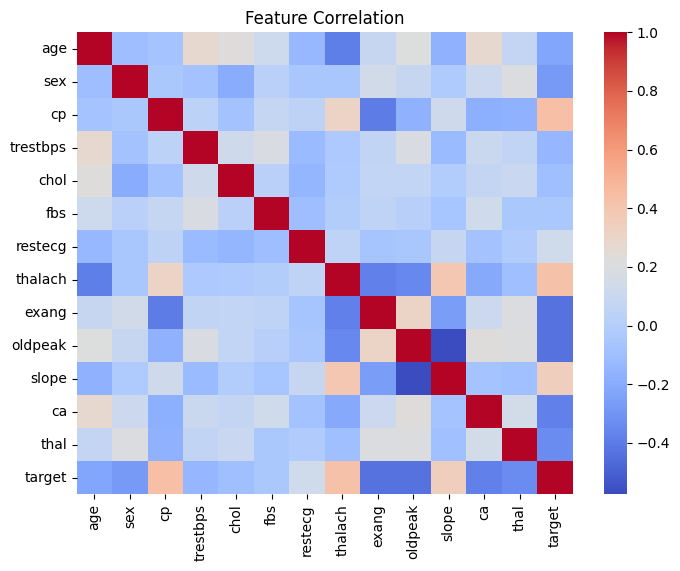

In [7]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [ ]:
nn_model = tf.keras.models.Sequential()

nn_model.add(tf.keras.layers.Dense(16, activation='relu', input_shape=(x_train.shape[1],)))
nn_model.add(tf.keras.layers.Dense(8, activation='relu'))
nn_model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = nn_model.fit(
    x_train, y_train,
    epochs=50,
    validation_data=(x_test, y_test),
    verbose=0
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
lr = LogisticRegression()
lr.fit(x_train, y_train)

lr_pred = lr.predict(x_test)
lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.7951219512195122


In [ ]:
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)

dt_pred = dt.predict(x_test)
dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.9853658536585366


In [ ]:
loss, nn_acc = nn_model.evaluate(x_test, y_test, verbose=0)
print("Neural Network Accuracy:", nn_acc)

Neural Network Accuracy: 0.8585366010665894


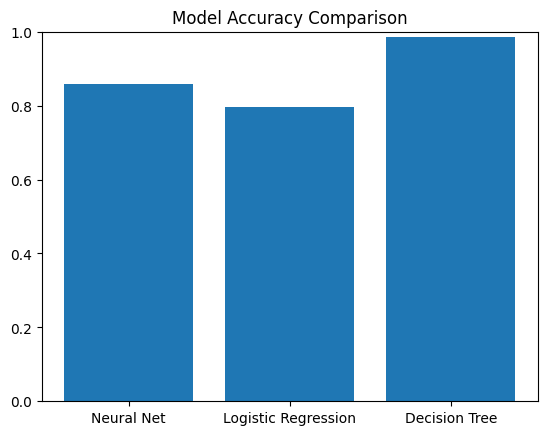

In [ ]:
models = ["Neural Net", "Logistic Regression", "Decision Tree"]
acc = [nn_acc, lr_acc, dt_acc]

plt.bar(models, acc)
plt.title("Model Accuracy Comparison")
plt.ylim(0,1)
plt.show()

In [ ]:
sample = x_test[0].reshape(1, -1)

prediction = nn_model.predict(sample)

if prediction[0][0] > 0.5:
    print("Heart Disease Detected ❤️")
else:
    print("No Heart Disease 💚")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Heart Disease Detected ❤️


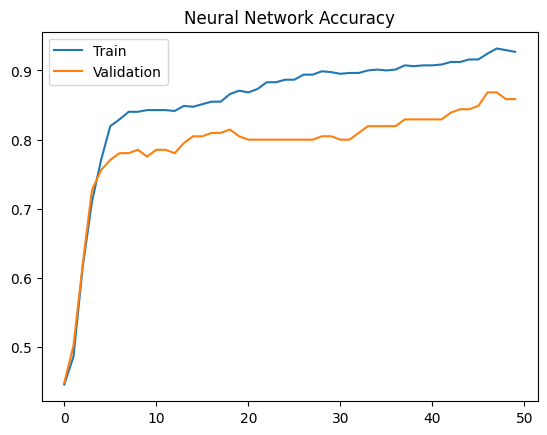

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Neural Network Accuracy")
plt.legend(['Train', 'Validation'])
plt.show()